# Compare trained models

Loads training summaries and evaluation outputs for a session and aggregates key metrics across models.


In [6]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package to ensure using the local code.
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RUNS_ROOT = Path("../training_runs")
RUNS_ROOT.mkdir(exist_ok=True)

# Leave None to auto-pick the most recent training session (prefix before _<modelname>), or set explicitly.
SESSION_TAG = None

EXPERIMENTS = [
    "resnet18",
    "resnet34",
    "resnet50",
    "efficientnet_b1",
    "efficientnet_b2",
    "convnext_tiny",
    "convnext_small",
    "custom_cnn",
]

def resolve_session_tag():
    if SESSION_TAG:
        return SESSION_TAG
    candidates = []
    for exp in EXPERIMENTS:
        for path in RUNS_ROOT.glob(f"*_{exp}"):
            prefix = path.name[: -len(f"_{exp}")]
            candidates.append((path.stat().st_mtime, prefix))
    if not candidates:
        raise FileNotFoundError("No training runs found. Set SESSION_TAG manually if needed.")
    candidates.sort()
    return candidates[-1][1]

SESSION_PREFIX = resolve_session_tag()
print(f"Comparison session prefix: {SESSION_PREFIX}")


Comparison session prefix: resampled_20251206-162829


In [8]:
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

## Load runs and build comparison table


In [9]:
def load_run(exp_name: str, session_prefix: str):
    run_dir = RUNS_ROOT / f"{session_prefix}_{exp_name}"
    if not run_dir.exists():
        print(f"Skipping missing run_dir: {run_dir}")
        return None

    cfg_path = run_dir / "config.json"
    train_summary_path = run_dir / "train_summary.json"
    eval_metrics_path = run_dir / "eval_metrics.json"

    if not cfg_path.exists():
        print(f"Missing config for {run_dir}, skipping.")
        return None

    cfg = json.loads(cfg_path.read_text())
    train_summary = json.loads(train_summary_path.read_text()) if train_summary_path.exists() else {}
    eval_metrics = json.loads(eval_metrics_path.read_text()) if eval_metrics_path.exists() else {}

    row = {
        "experiment": exp_name,
        "run_dir": str(run_dir),
        "model": cfg.get("model_name"),
        "image_size": cfg.get("image_size"),
        "batch_size": cfg.get("batch_size"),
        "epochs_ran": len(train_summary.get("history", [])),
        "best_val_metric": train_summary.get("best_metric"),
    }

    # Add raw/calibrated metrics if present
    for split in ("val_raw", "val_calibrated", "test_raw", "test_calibrated"):
        metrics = eval_metrics.get(split)
        if not metrics:
            continue
        for k, v in metrics.items():
            row[f"{split}_{k}"] = v

    if "temperature" in eval_metrics:
        row["temperature"] = eval_metrics["temperature"]

    return row

rows = []
for exp in EXPERIMENTS:
    row = load_run(exp, SESSION_PREFIX)
    if row:
        rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df

,experiment,run_dir,model,image_size,batch_size,epochs_ran,best_val_metric,val_raw_accuracy,val_raw_macro_precision,val_raw_macro_recall,...,test_raw_macro_f1,test_raw_brier,test_raw_ece,test_calibrated_accuracy,test_calibrated_macro_precision,test_calibrated_macro_recall,test_calibrated_macro_f1,test_calibrated_brier,test_calibrated_ece,temperature
0,resnet18,../training_runs/resampled_20251206-162829_res...,resnet18,256,64,24,0.998370,0.998501,0.997914,0.998833,...,0.995534,0.003410,0.026484,0.9960,0.994825,0.996254,0.995534,0.002910,0.010590,0.784611
1,resnet34,../training_runs/resampled_20251206-162829_res...,resnet34,256,48,24,0.998367,0.998501,0.998835,0.997905,...,0.995521,0.003301,0.026822,0.9960,0.996252,0.994801,0.995521,0.002823,0.010342,0.792405
2,resnet50,../training_runs/resampled_20251206-162829_res...,resnet50,256,32,38,1.000000,1.000000,1.000000,1.000000,...,0.997767,0.001701,0.027340,0.9980,0.997054,0.998491,0.997767,0.001154,0.010905,0.780676
3,efficientnet_b1,../training_runs/resampled_20251206-162829_eff...,efficientnet_b1,240,48,26,0.999456,0.999500,0.999611,0.999302,...,0.997208,0.002055,0.024706,0.9975,0.996672,0.997750,0.997208,0.001617,0.010235,0.791169
4,efficientnet_b2,../training_runs/resampled_20251206-162829_eff...,efficientnet_b2,260,36,25,0.999456,0.999500,0.999611,0.999302,...,0.996648,0.002786,0.025819,0.9970,0.996290,0.997009,0.996648,0.002333,0.010035,0.782305
5,convnext_tiny,../training_runs/resampled_20251206-162829_con...,convnext_tiny,256,48,45,0.998913,0.999000,0.998913,0.998913,...,0.996091,0.003818,0.021760,0.9965,0.995556,0.996632,0.996091,0.003463,0.006773,0.805547
6,convnext_small,../training_runs/resampled_20251206-162829_con...,convnext_small,256,32,40,0.999456,0.999500,0.999303,0.999611,...,0.997764,0.001849,0.025884,0.9980,0.997764,0.997764,0.997764,0.001321,0.010430,0.790844
7,custom_cnn,../training_runs/resampled_20251206-162829_cus...,custom_cnn,256,96,47,0.991332,0.992004,0.989599,0.993156,...,0.989944,0.006839,0.025983,0.9910,0.989591,0.990300,0.989944,0.006268,0.012301,0.793064


## Quick plots


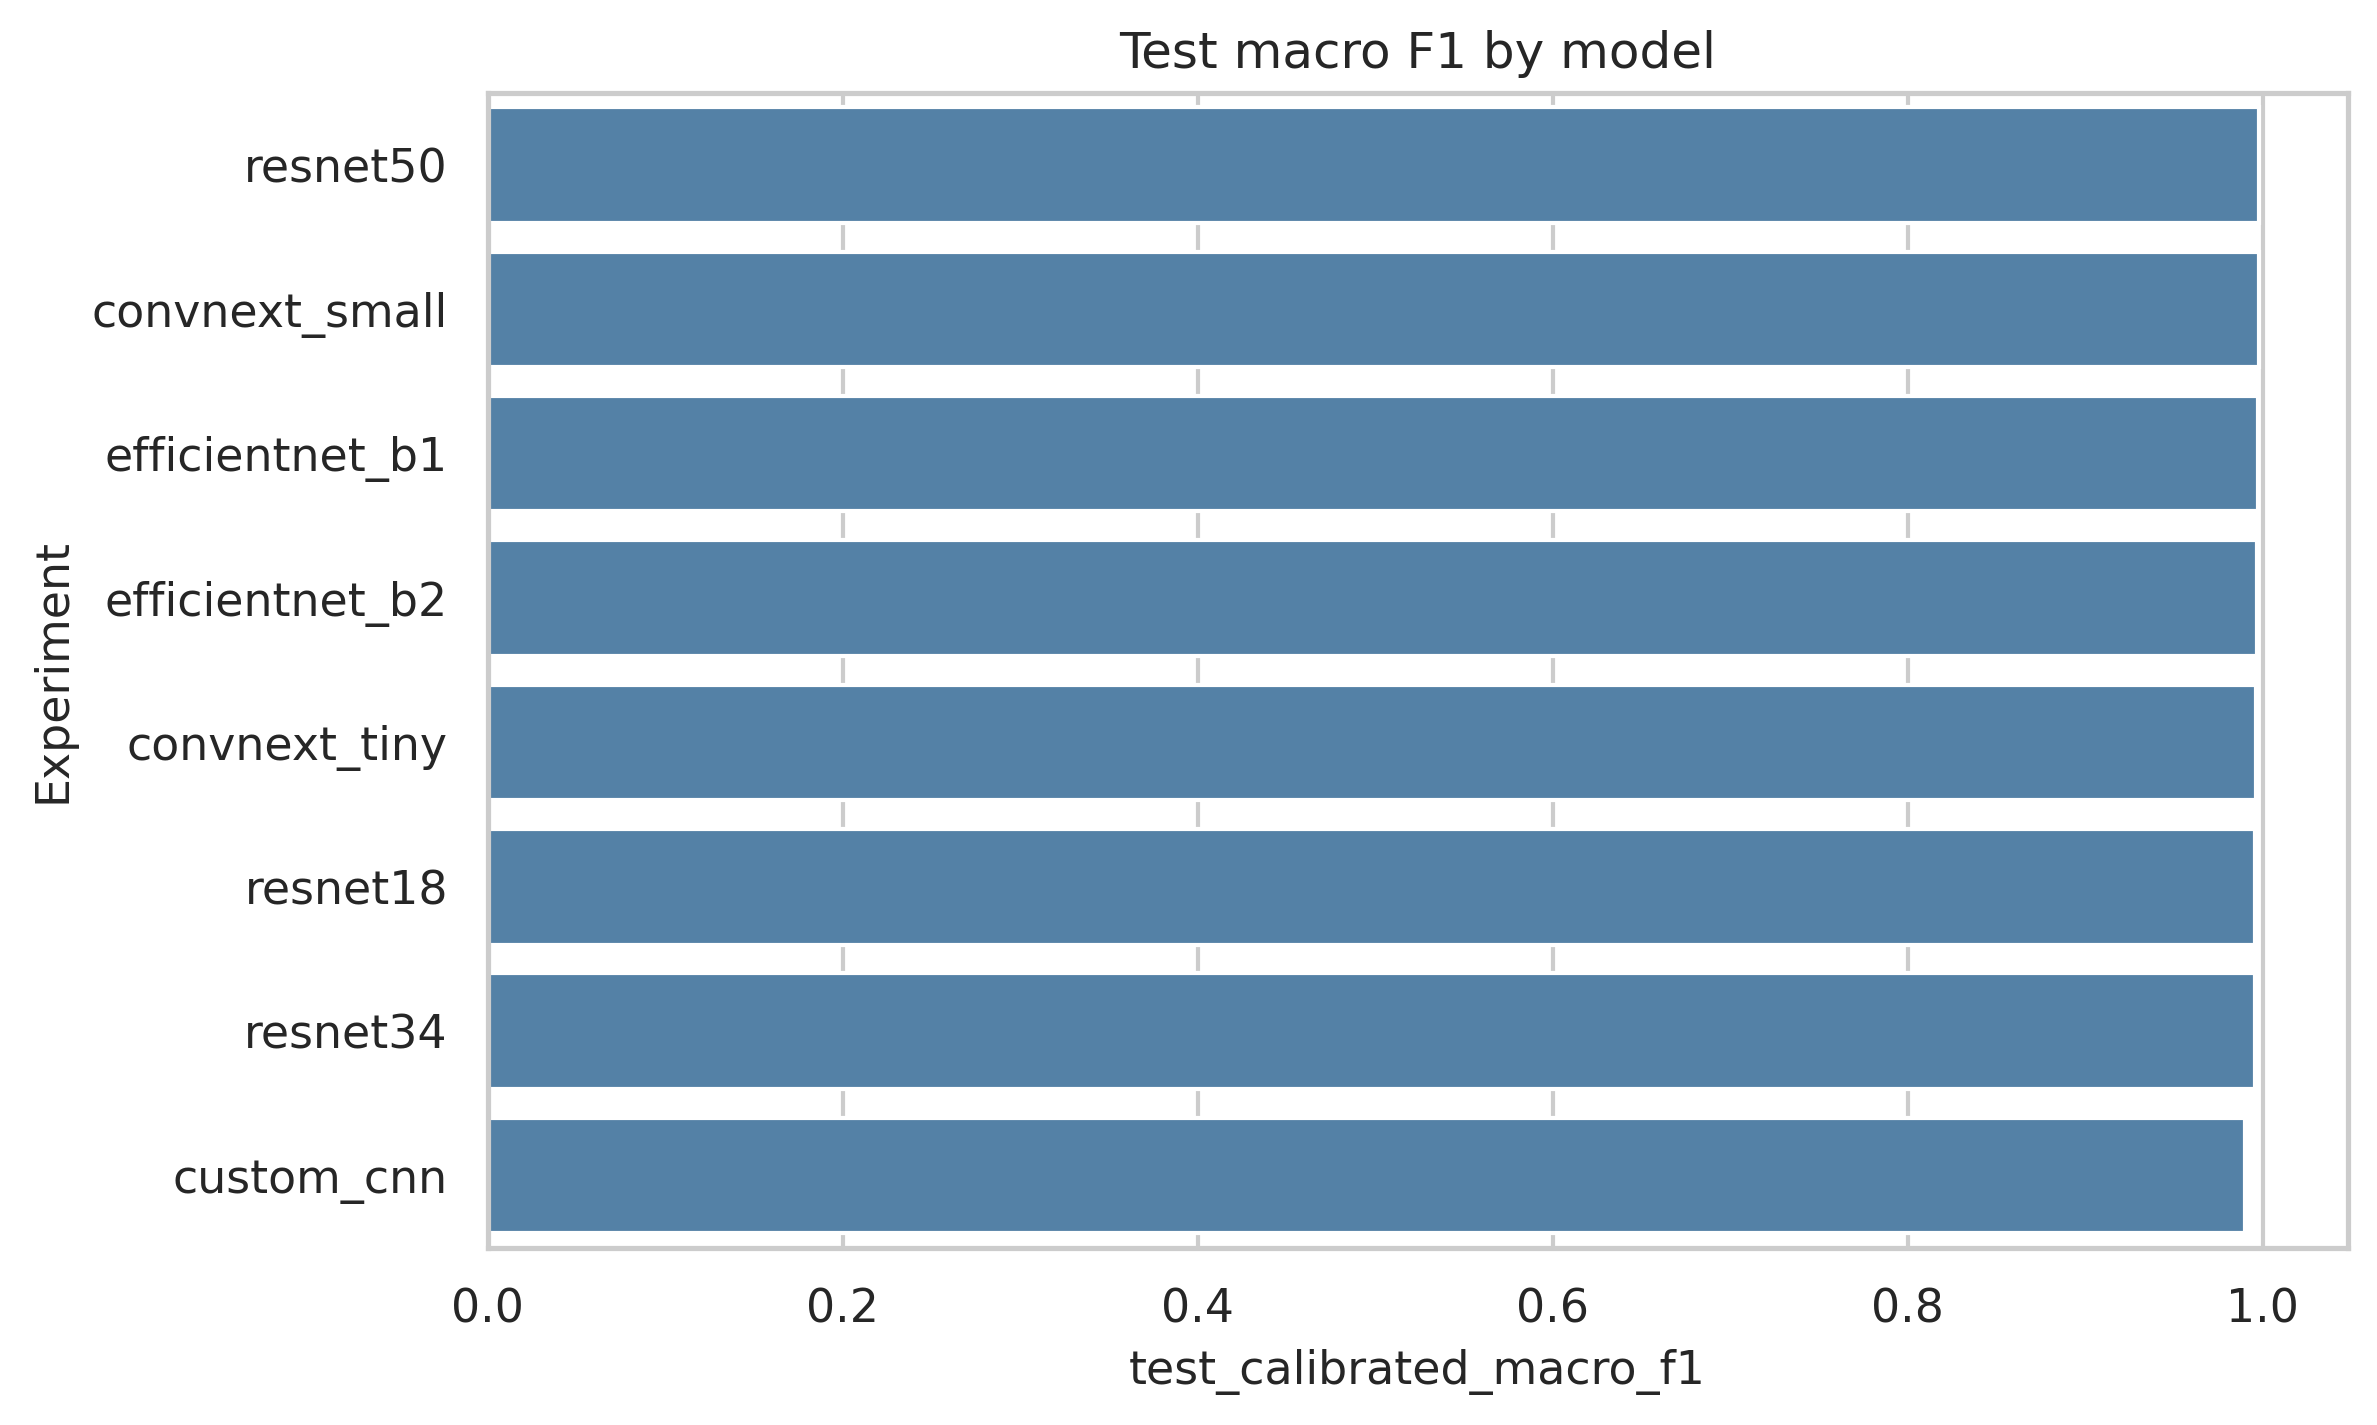

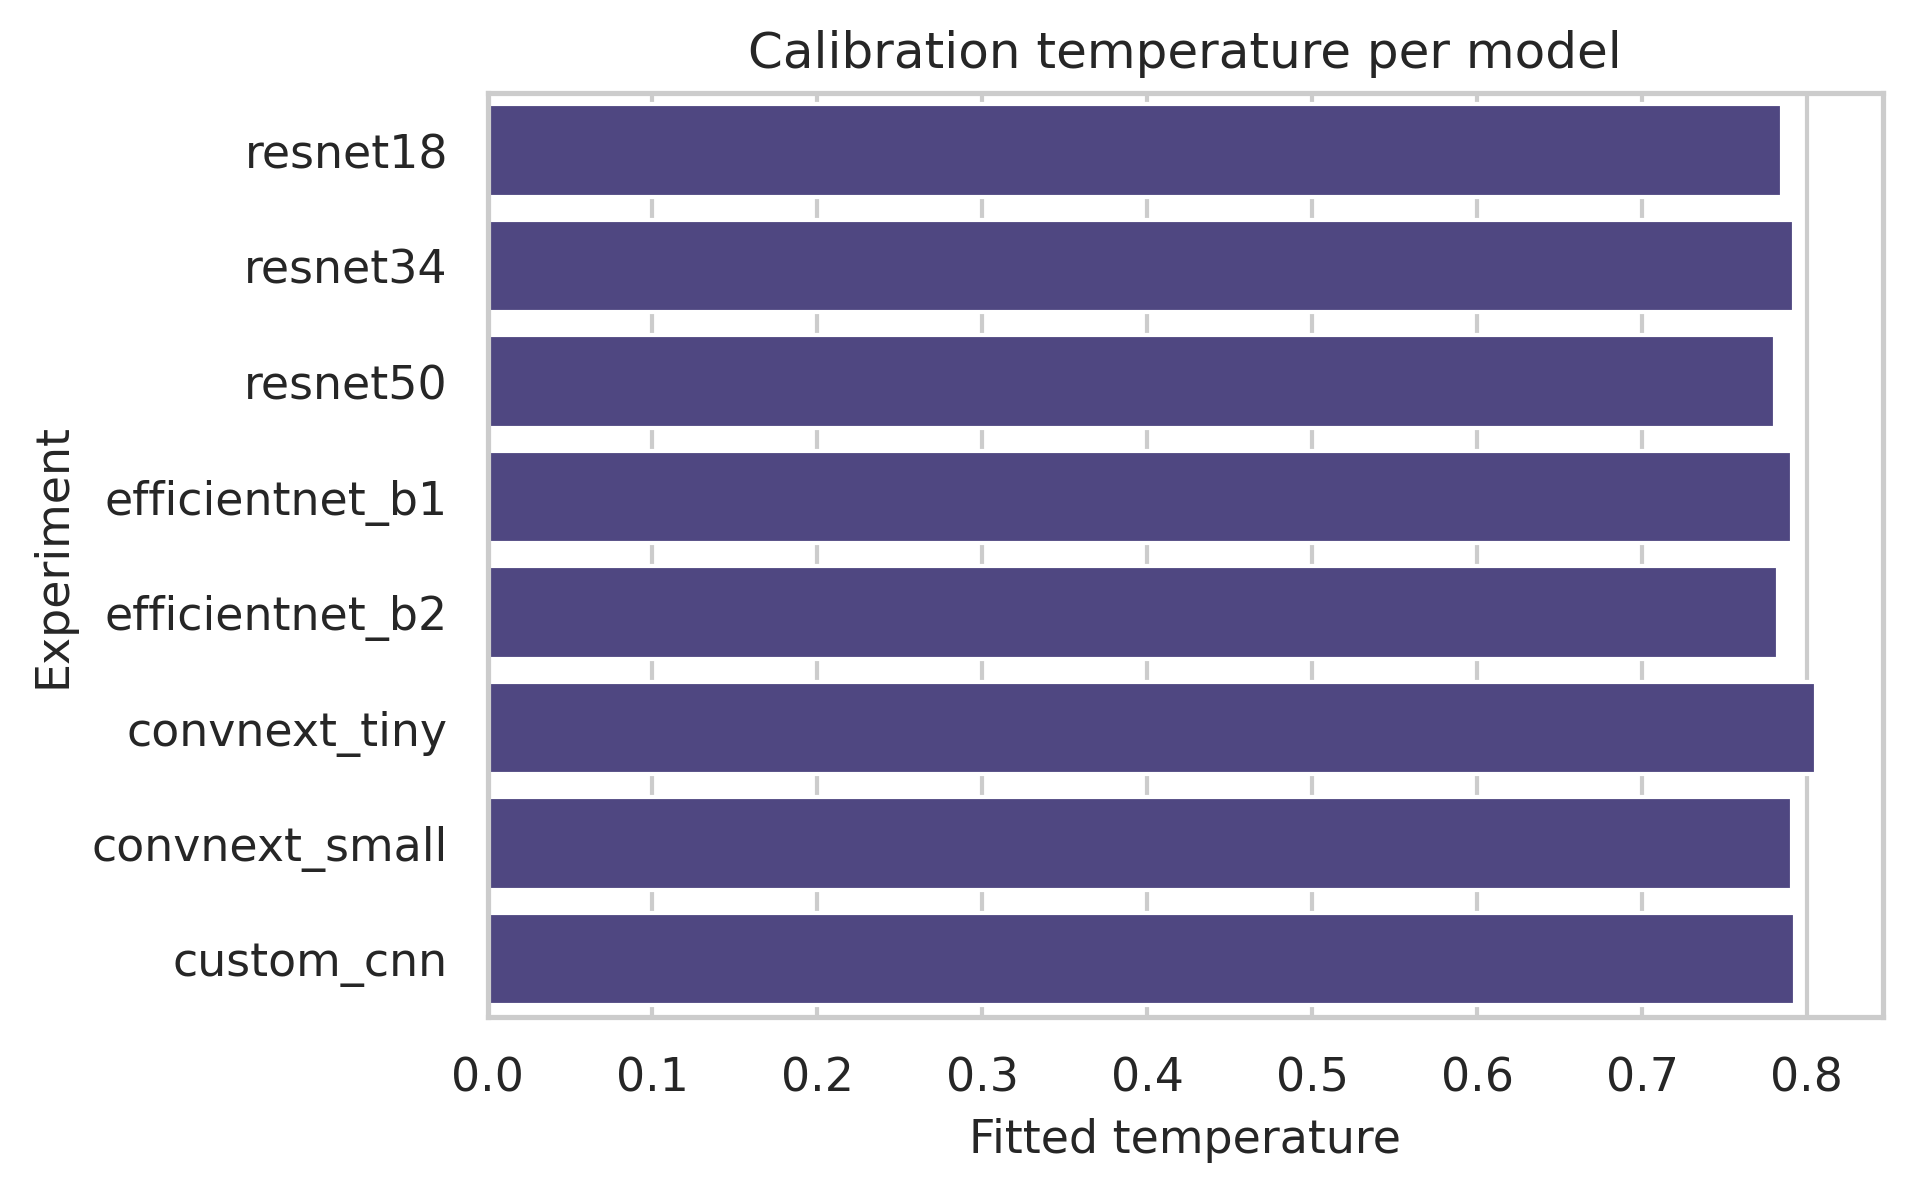

In [10]:
if comparison_df.empty:
    print("No runs to plot. Ensure SESSION_TAG matches your training/evaluation outputs.")
else:
    metric_col = "test_calibrated_macro_f1" if "test_calibrated_macro_f1" in comparison_df else "test_raw_macro_f1"
    if metric_col in comparison_df:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.barplot(data=comparison_df.sort_values(metric_col, ascending=False), x=metric_col, y="experiment", ax=ax, color="steelblue")
        ax.set_xlabel(metric_col)
        ax.set_ylabel("Experiment")
        ax.set_title("Test macro F1 by model")
        plt.show()

    if "temperature" in comparison_df:
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.barplot(data=comparison_df, x="temperature", y="experiment", ax=ax, color="darkslateblue")
        ax.set_xlabel("Fitted temperature")
        ax.set_ylabel("Experiment")
        ax.set_title("Calibration temperature per model")
        plt.show()
